In [ ]:
import pandas as pd
import numpy as np
import re
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import json
import kagglehub
import os
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
def scrape_box_office_mojo(url):
    response = requests.get(url)
    response.raise_for_status()  # Проверка на ошибки (4xx, 5xx)

    soup = BeautifulSoup(response.text, 'html.parser')

    # Находим таблицу с данными (нужно изучить HTML-структуру страницы)
    table = soup.find('table')  #  Это очень общий пример, скорее всего, понадобится более точный селектор

    data = []
    if table: #проверяем, что таблица существует
        for row in table.find_all('tr')[1:]:  # Пропускаем заголовок
            cols = row.find_all('td')
            if len(cols) > 1: #Условие, что строка не пустая
                try:
                    title = cols[1].text.strip()  # Название фильма (примерный индекс)
                    gross = cols[5].text.strip()  # Кассовые сборы (примерный индекс)
                    # Очистка данных о сборах (удаление $, запятых, приведение к числовому типу)
                    gross = float(gross.replace('$', '').replace(',', ''))
                    data.append({'title': title, 'gross': gross})
                except (ValueError, IndexError) as e:
                    print(f"Ошибка при обработке строки: {e}")
                    continue #Пропускаем строку

    return pd.DataFrame(data)

#Пример страницы с данными
url = "https://www.boxofficemojo.com/year/2023/" # URL страницы с кассовыми сборами за 2023 год

box_office_df = scrape_box_office_mojo(url)

print(box_office_df.head())
print(box_office_df.info()) #Вывод общей информации

                                 title        gross
0                               Barbie  636225983.0
1          The Super Mario Bros. Movie  574934330.0
2  Spider-Man: Across the Spider-Verse  381311319.0
3       Guardians of the Galaxy Vol. 3  358995815.0
4                          Oppenheimer  326101370.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   title   200 non-null    object 
 1   gross   200 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.3+ KB
None


100%|██████████| 8.89M/8.89M [00:00<00:00, 146MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tmdb/tmdb-movie-metadata/versions/2
movies_df columns: Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')
credits_df columns: Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   budget                     4803 non-null   int64  
 1   genres                     4803 non-null   object 
 2   homepage                   1712 non-null   object 
 3   id                         4803 non-null   int64  
 4   keywords              

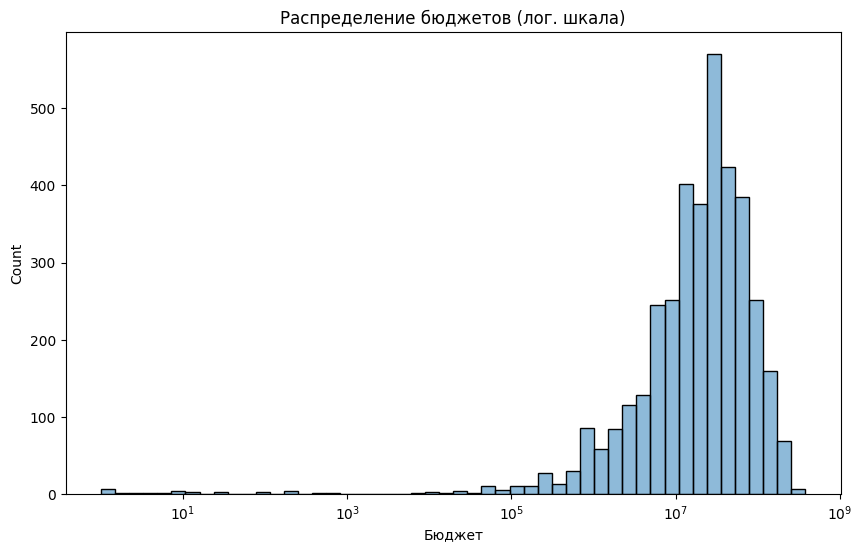

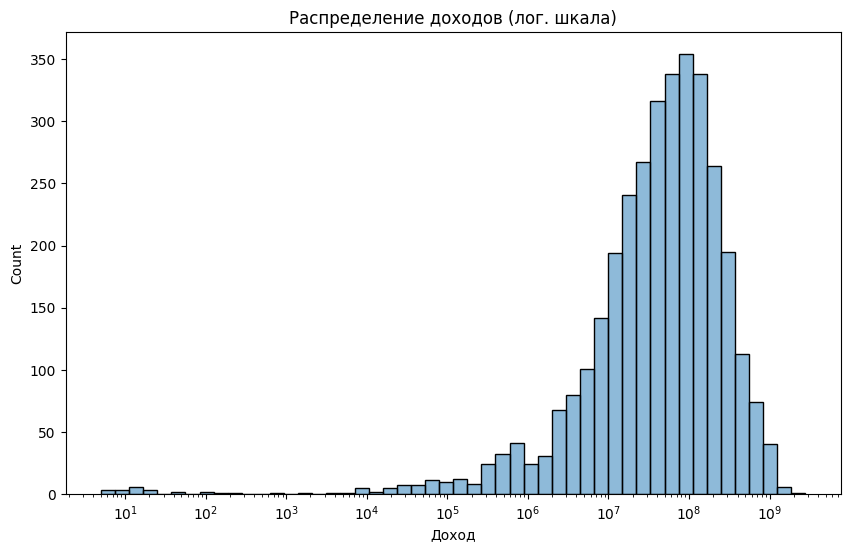

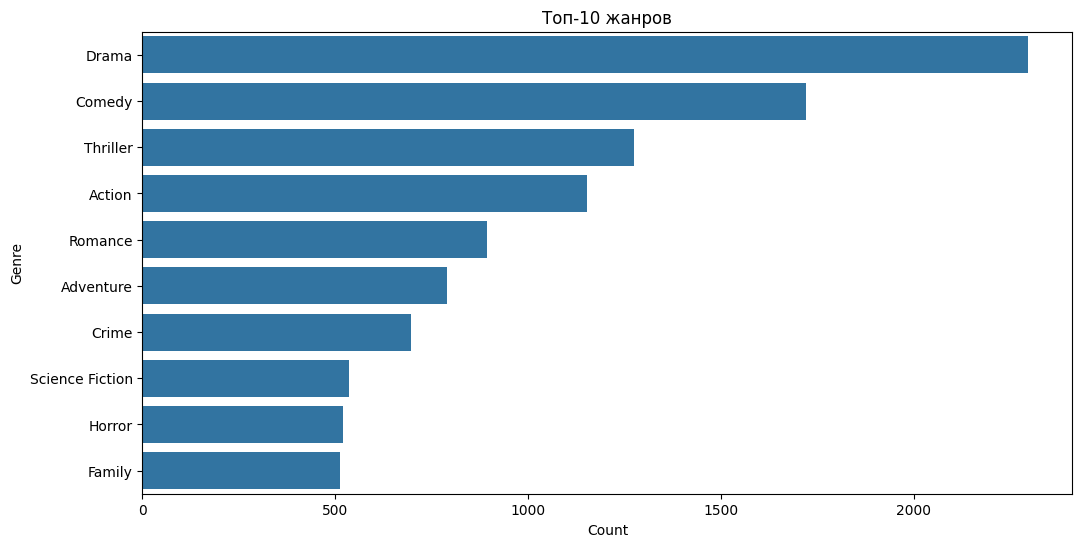

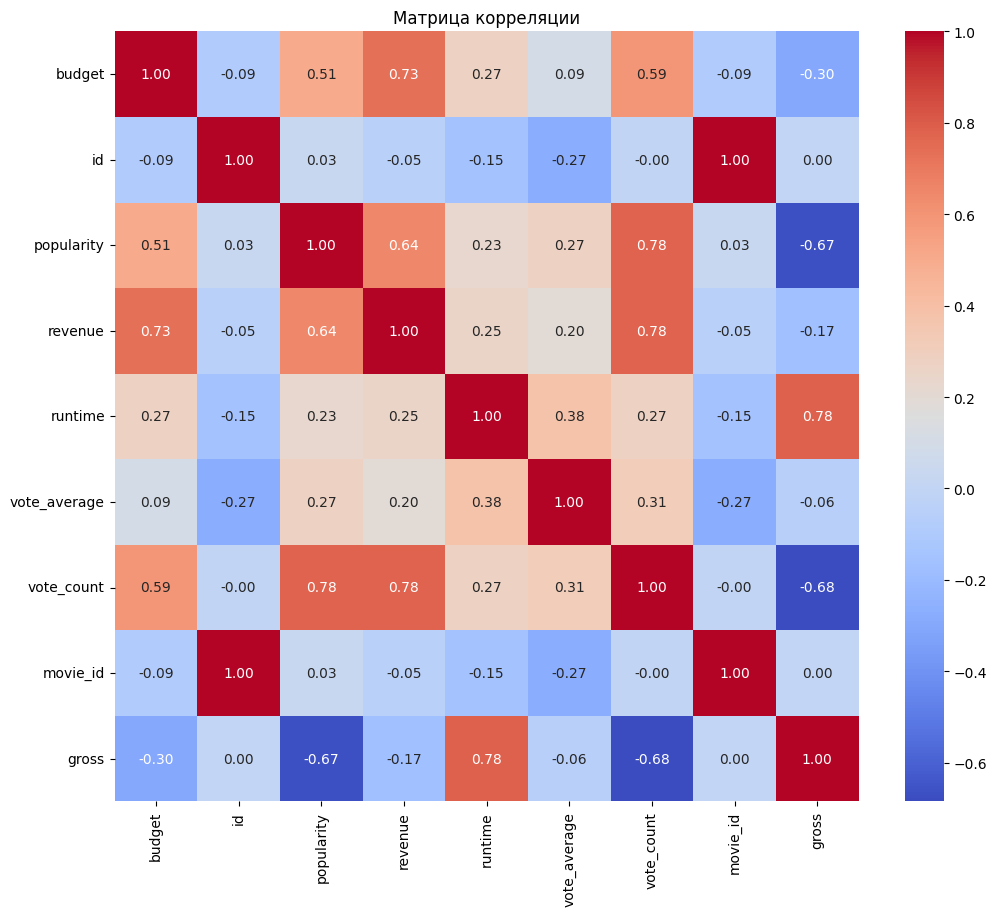

In [ ]:
# 1. Загрузка данных TMDB
try:
    path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
    print("Path to dataset files:", path)

    movies_df = pd.read_csv(os.path.join(path, 'tmdb_5000_movies.csv'))
    credits_df = pd.read_csv(os.path.join(path, 'tmdb_5000_credits.csv'))

except Exception as e:
    print(f"Ошибка при загрузке: {e}")
    exit()

# Проверка названий столбцов (для уверенности)
print("movies_df columns:", movies_df.columns)
print("credits_df columns:", credits_df.columns)

# 2. Объединение датасетов
# Используем left_on='id' (из movies_df) и right_on='movie_id' (из credits_df)
merged_tmdb_df = pd.merge(movies_df, credits_df, left_on='id', right_on='movie_id')

# 3. Скрейпинг Box Office Mojo
def scrape_box_office_mojo(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        table = soup.find('table')
        data = []
        if table:
            for row in table.find_all('tr')[1:]:
                cols = row.find_all('td')
                if len(cols) > 1:
                    try:
                        title = cols[1].text.strip()
                        gross = float(cols[5].text.strip().replace('$', '').replace(',', ''))
                        data.append({'title': title, 'gross': gross})
                    except (ValueError, IndexError):
                        continue
        return pd.DataFrame(data)
    except requests.exceptions.RequestException:
        return pd.DataFrame()

url = "https://www.boxofficemojo.com/year/2023/"
box_office_df = scrape_box_office_mojo(url)

# 4. Очистка названий
def clean_title(title):
    return re.sub(r'[^\w\s]', '', title.lower()).strip() if isinstance(title, str) else ''

# 5. Применение очистки
merged_tmdb_df['title_cleaned'] = merged_tmdb_df['title_x'].apply(clean_title) #title_x после merge
box_office_df['title_cleaned'] = box_office_df['title'].apply(clean_title)

# 6. Объединение TMDB и Box Office Mojo
final_merged_df = pd.merge(merged_tmdb_df, box_office_df, on='title_cleaned', how='left')

# 7. EDA
def extract_json_data(json_str, key='name'):
    try:
        return [item[key] for item in json.loads(json_str)]
    except (json.JSONDecodeError, TypeError):
        return []

final_merged_df['genres_list'] = final_merged_df['genres'].apply(extract_json_data)
final_merged_df['keywords_list'] = final_merged_df['keywords'].apply(extract_json_data)
final_merged_df['production_companies_list'] = final_merged_df['production_companies'].apply(extract_json_data)
final_merged_df['cast_list'] = final_merged_df['cast'].apply(lambda x: extract_json_data(x, 'name'))
final_merged_df['character_list'] = final_merged_df['cast'].apply(lambda x: extract_json_data(x, 'character'))

def extract_crew_data(json_str, job_title):
    try:
        return [m['name'] for m in json.loads(json_str) if m['job'] == job_title]
    except (json.JSONDecodeError, TypeError):
        return []

final_merged_df['director_list'] = final_merged_df['crew'].apply(lambda x: extract_crew_data(x, 'Director'))

# Визуализации
print(final_merged_df.info())
print(final_merged_df.describe())
print(final_merged_df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.histplot(final_merged_df['budget'], bins=50, kde=True, log_scale=True)
plt.title('Распределение бюджетов (лог. шкала)')
plt.xlabel('Бюджет')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(final_merged_df['revenue'], bins=50, kde=True, log_scale=True)
plt.title('Распределение доходов (лог. шкала)')
plt.xlabel('Доход')
plt.show()

genre_counts = {}
for genres in final_merged_df['genres_list']:
    for genre in genres:
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values('Count', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Genre', data=genre_df.head(10))
plt.title('Топ-10 жанров')
plt.show()

correlation_matrix = final_merged_df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции')
plt.show()

ЗАДАНИЕ 2 часть 1

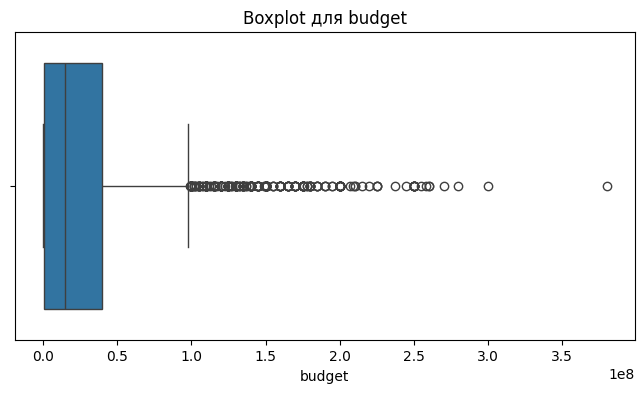

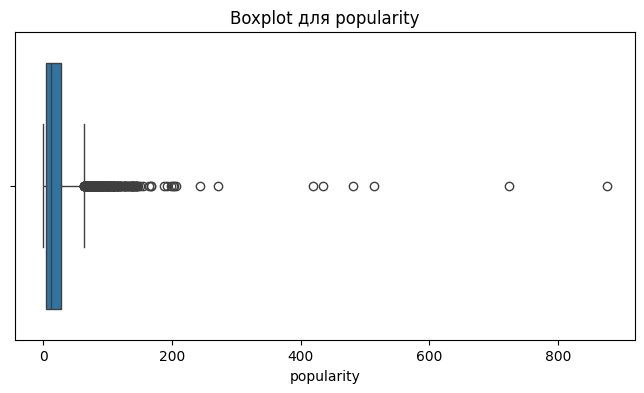

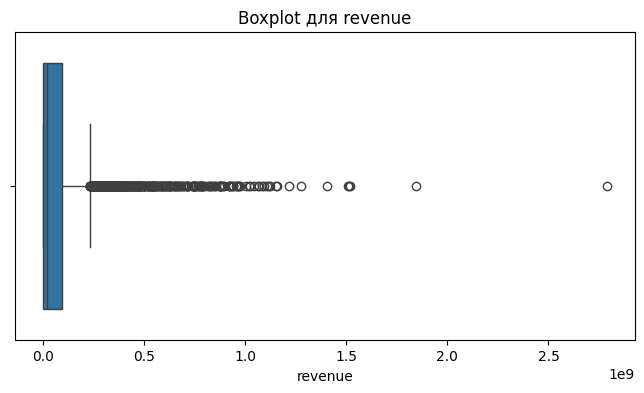

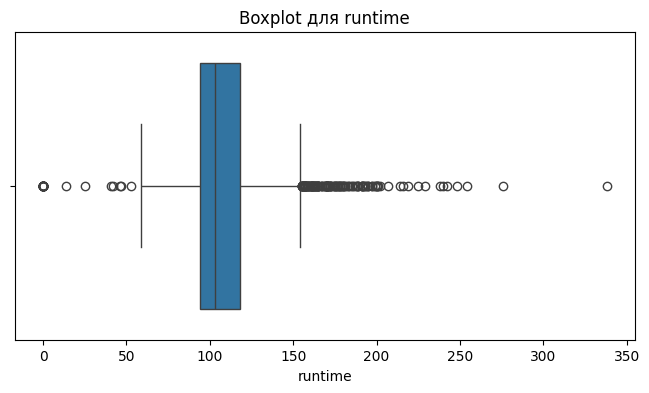

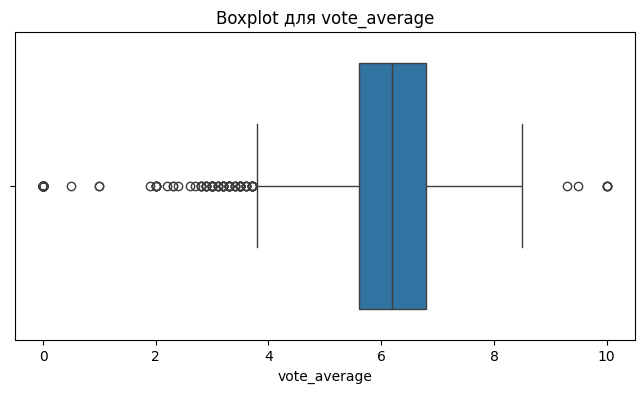

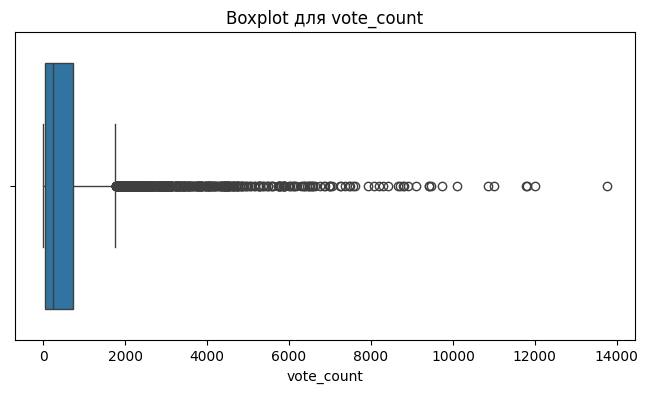

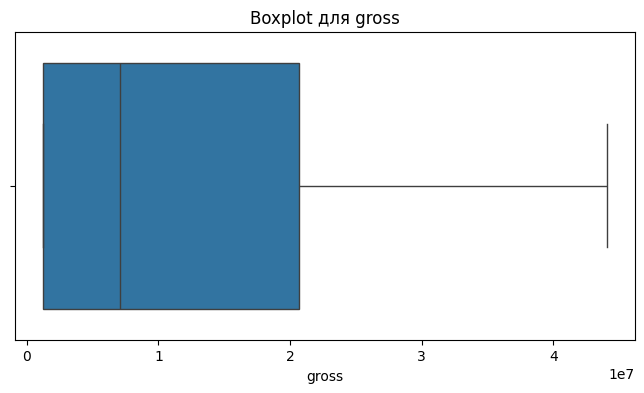

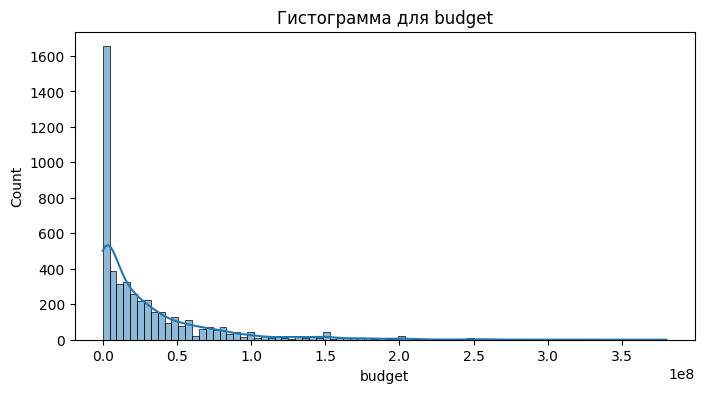

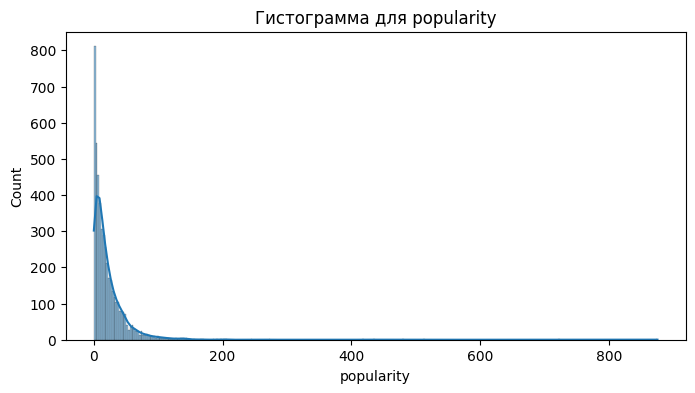

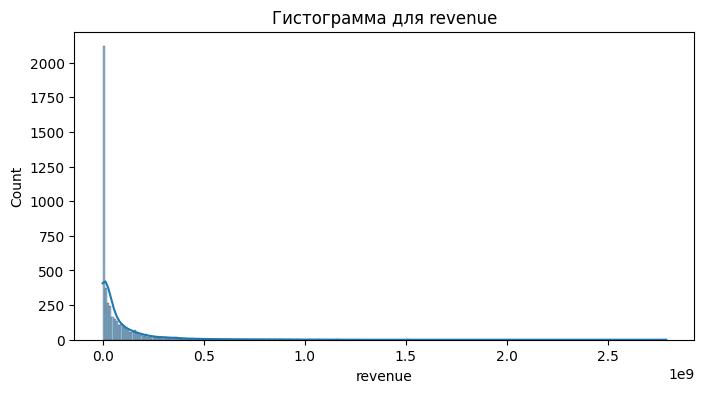

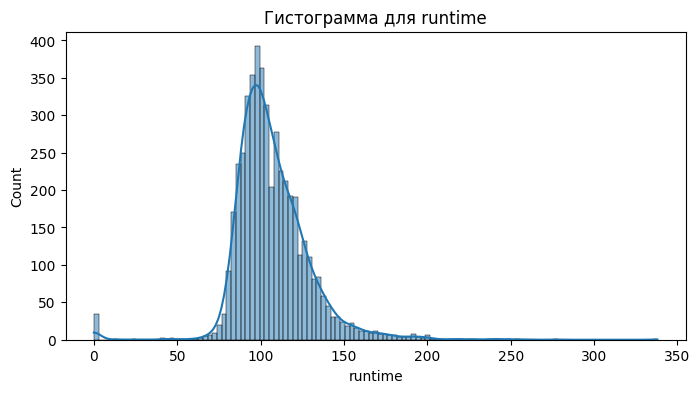

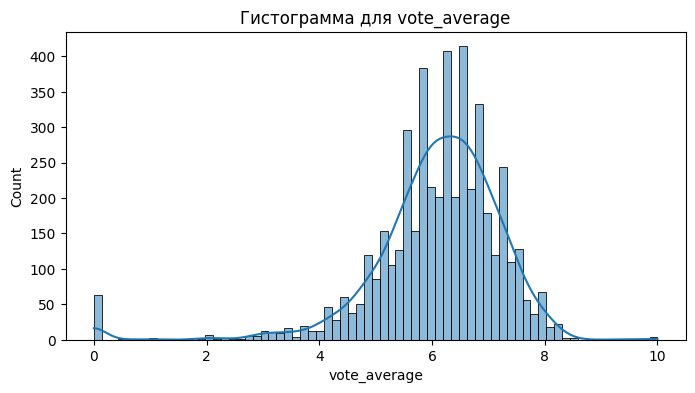

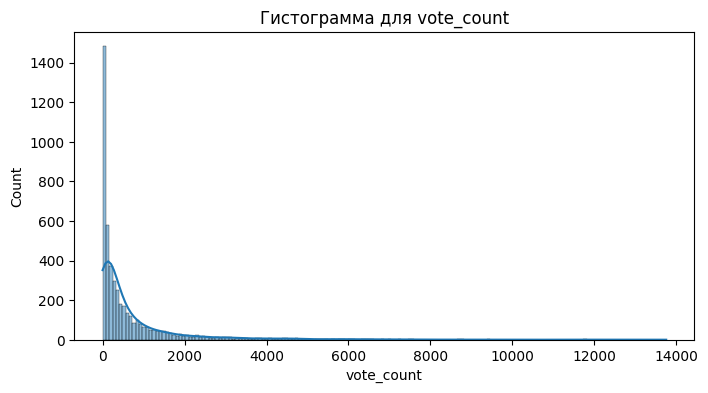

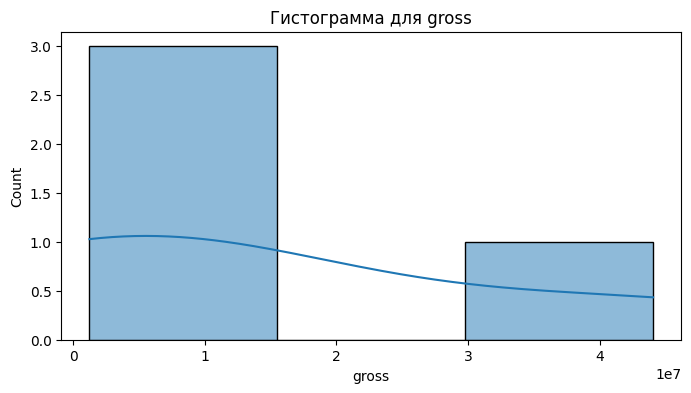

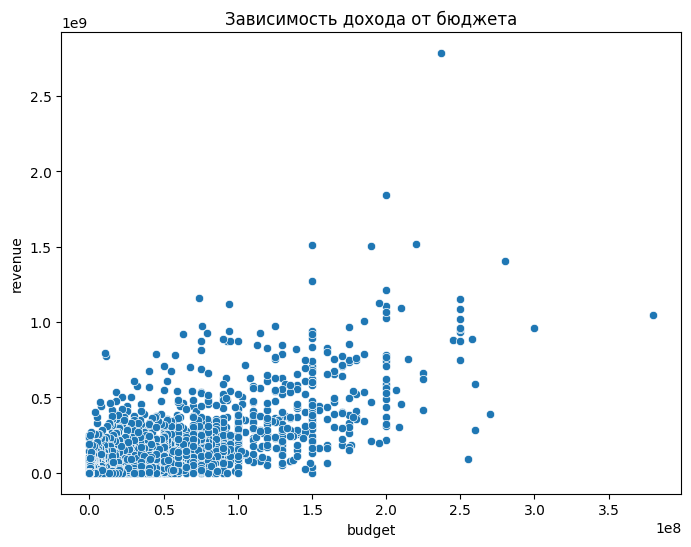


Z-scores:
         budget  popularity    revenue   runtime  vote_average  vote_count  \
0     5.107181    4.053183  16.615709  2.438652      0.927451    8.999729   
1     6.654402    3.696258   5.396331  2.748318      0.676297    3.086200   
2     5.303653    2.699638   4.903054  1.819320      0.173990    3.058657   
3     5.426449    2.854798   6.157440  2.571366      1.262322    6.817394   
4     5.672039    0.705198   1.239734  1.111513      0.006554    1.161467   
...        ...         ...        ...       ...           ...         ...   
4798  0.707916    0.227028   0.492629  1.144624      0.425143    0.366329   
4799  0.713098    0.655378   0.505162  0.967672      0.160882    0.555076   
4800  0.713319    0.630170   0.505162  0.580657      0.760015    0.554266   
4801  0.713319    0.648637   0.505162  0.392579      0.328318    0.553456   
4802  0.713319    0.614912   0.505162  0.746483      0.173990    0.546165   

         gross  
0     0.011721  
1     0.011721  
2     0.0117

In [ ]:
# 1. Ящики с усами (boxplots) для числовых признаков
numerical_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count', 'gross']
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=final_merged_df[col])
    plt.title(f'Boxplot для {col}')
    plt.show()

# 2. Гистограммы (histograms) - полезно посмотреть на распределение
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(final_merged_df[col], kde=True)
    plt.title(f'Гистограмма для {col}')
    plt.show()

# 3. Диаграммы рассеяния (scatter plots) - для поиска выбросов во взаимосвязи двух признаков
plt.figure(figsize=(8, 6))
sns.scatterplot(x='budget', y='revenue', data=final_merged_df)
plt.title('Зависимость дохода от бюджета')
plt.show()

# 4. Z-score (для одномерных данных)
from scipy import stats
z_scores = np.abs(stats.zscore(final_merged_df[numerical_cols].fillna(final_merged_df[numerical_cols].median()))) # Заполняем пропуски медианой
print("\nZ-scores:\n", z_scores)

#  Определяем выбросы (например, Z-score > 3)
outliers_z = (z_scores > 3).any(axis=1)
print("\nКоличество выбросов (Z-score > 3):", outliers_z.sum())
#print(final_merged_df[outliers_z]) #Вывод строк

# 5. IQR (Interquartile Range) - межквартильный размах
Q1 = final_merged_df[numerical_cols].quantile(0.25)
Q3 = final_merged_df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
print("\nIQR:\n", IQR)

outliers_iqr = ((final_merged_df[numerical_cols] < (Q1 - 1.5 * IQR)) | (final_merged_df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
print("\nКоличество выбросов (IQR):", outliers_iqr.sum())

# 6. DBSCAN (для многомерных данных) - кластеризация на основе плотности
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

#  Стандартизируем данные
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_merged_df[numerical_cols].fillna(final_merged_df[numerical_cols].median()))

#  Подбираем параметры eps и min_samples (это требует экспериментов)
dbscan = DBSCAN(eps=3, min_samples=5)  # Примерные значения
clusters = dbscan.fit_predict(scaled_data)

#  Выбросы - это точки, помеченные как -1
outliers_dbscan = (clusters == -1)
print("\nКоличество выбросов (DBSCAN):", outliers_dbscan.sum())

Пропуски: В датасете присутствуют пропущенные значения в числовых признаках, таких как runtime, budget, revenue, gross, а также в категориальном признаке homepage. Процент пропусков и их расположение требуют более детального анализа (как обсуждалось в предыдущем ответе), но уже ясно, что они есть и требуют обработки.

Гипотезы о причинах пропусков:
runtime: Пропуски могут быть связаны с тем, что данные о продолжительности фильма не всегда доступны на момент сбора данных, особенно для менее известных или еще не выпущенных фильмов.

budget и revenue: Пропуски могут возникать из-за коммерческой тайны, нежелания студий раскрывать финансовые данные для некоторых фильмов, либо данные просто не были собраны для старых или независимых фильмов.

gross: Пропуски в gross (кассовые сборы в США) могут быть связаны с фильмами, которые не выходили в широкий прокат в США, либо данные о сборах не были зафиксированы в базе данных. Заполнение нулем (как вы и сделали) в этом случае выглядит логичным предположением, что фильм не имел значительных сборов в США.

homepage: Пропуски здесь, вероятно, означают, что у фильма просто нет официального веб-сайта, что часто встречается для менее крупных проектов.

Выбросы: Анализ с помощью боксплотов, гистограмм, диаграмм рассеяния, Z-score, IQR и DBSCAN (как показано в вашем коде) выявил наличие выбросов в числовых признаках, особенно в budget, revenue, popularity, vote_count, gross. Эти выбросы, вероятно, представляют собой фильмы с очень высокими бюджетами, кассовыми сборами или популярностью – блокбастеры или очень успешные фильмы. Важно понимать, что в контексте киноиндустрии такие "выбросы" могут быть не ошибками, а реальными экстремальными значениями, отражающими специфику индустрии.

ЗАДАНИЕ 2 ЧАСТЬ 2

<ipython-input-20-994dc0f9d13f>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[col] = train_data[col].fillna(train_data[col].mean())


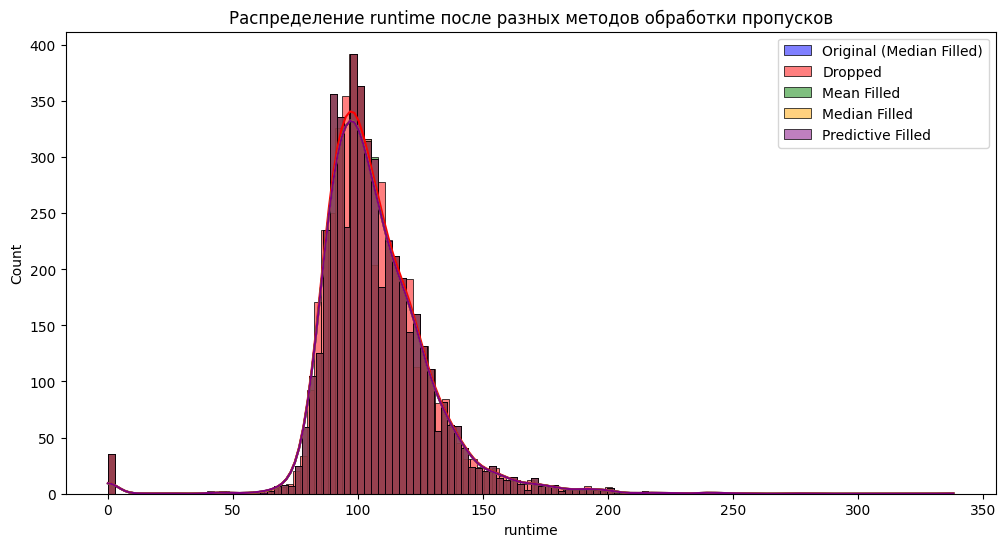


Log Transformed (Corrected):
RMSE (log(budget) -> log(revenue)): 6.40
R^2  (log(budget) -> log(revenue)): 0.331

Сравнение RMSE для разных методов обработки:
Original (Median Filled):
RMSE (budget -> revenue): 97137084.35

Dropped:
RMSE (budget -> revenue): 99174375.25

Mean Filled:
RMSE (budget -> revenue): 97137084.35

Median Filled:
RMSE (budget -> revenue): 97137084.35

Zero Filled (gross):
RMSE (gross -> revenue): 161461332.89

Predictive Filled:
RMSE (budget -> revenue): 97137084.35

No Outliers (IQR):
RMSE (budget -> revenue): 32844489.49

Winsorized:
RMSE (budget -> revenue): 66868332.19

Log Transformed:
RMSE (budget -> revenue): 5.92


np.float64(5.924601985746203)

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Создадим копию датафрейма для экспериментов
df_processed = final_merged_df.copy()

# --- Обработка пропусков ---

# 1. Удаление строк с пропусками в 'runtime' (их немного)
df_dropped = df_processed.dropna(subset=['runtime'])

# 2. Заполнение 'runtime' средним
df_mean_filled = df_processed.copy()
df_mean_filled['runtime'] = df_mean_filled['runtime'].fillna(df_mean_filled['runtime'].mean())

# 3. Заполнение 'runtime' медианой
df_median_filled = df_processed.copy()
df_median_filled['runtime'] = df_median_filled['runtime'].fillna(df_median_filled['runtime'].median())

# 4. Заполнение 'gross' нулем (если нет данных о сборах, считаем, что фильм не выходил в широкий прокат)
df_zero_filled = df_processed.copy()
df_zero_filled['gross'] = df_zero_filled['gross'].fillna(0)

# 5. Предиктивное заполнение 'runtime' (используем линейную регрессию)
df_predictive_filled = df_processed.copy()

#  Создаем датасет для обучения модели (только строки без пропусков в 'runtime')
train_data = df_predictive_filled.dropna(subset=['runtime'])

#  Выбираем признаки для обучения (можно добавить другие)
features = ['budget', 'popularity', 'vote_average', 'vote_count']

#  Заполняем пропуски в этих признаках средним (для простоты)
for col in features:
    train_data[col] = train_data[col].fillna(train_data[col].mean())
    df_predictive_filled[col] = df_predictive_filled[col].fillna(df_predictive_filled[col].mean()) #и в исходном датасете

#  Обучаем модель
model = LinearRegression()
model.fit(train_data[features], train_data['runtime'])

#  Предсказываем пропущенные значения 'runtime'
missing_runtime_indices = df_predictive_filled['runtime'].isnull()
predicted_runtime = model.predict(df_predictive_filled[missing_runtime_indices][features])

#  Заполняем пропуски предсказанными значениями
df_predictive_filled.loc[missing_runtime_indices, 'runtime'] = predicted_runtime

# 6. Индикатор пропущенных значений для 'homepage'
df_processed['homepage_missing'] = df_processed['homepage'].isnull().astype(int)

# --- Обработка выбросов ---

# 1. Удаление выбросов (по IQR)
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df_no_outliers = df_processed.copy()
for col in ['budget', 'revenue', 'popularity', 'runtime', 'vote_count', 'gross']:
    # Сначала заполним пропуски, чтобы не потерять много данных при удалении выбросов
    df_no_outliers[col] = df_no_outliers[col].fillna(df_no_outliers[col].median())
    df_no_outliers = remove_outliers_iqr(df_no_outliers, col)


# 2. Винзоризация (замена на 5-й и 95-й перцентили)
def winsorize(df, col, lower_percentile=0.05, upper_percentile=0.95):
    df_copy = df.copy()
    lower_bound = df_copy[col].quantile(lower_percentile)
    upper_bound = df_copy[col].quantile(upper_percentile)
    df_copy[col] = np.where(df_copy[col] < lower_bound, lower_bound, df_copy[col])
    df_copy[col] = np.where(df_copy[col] > upper_bound, upper_bound, df_copy[col])
    return df_copy

df_winsorized = df_processed.copy()
for col in ['budget', 'revenue', 'popularity', 'runtime', 'vote_count', 'gross']:
    # Сначала заполним пропуски, чтобы не потерять много данных
    df_winsorized[col] = df_winsorized[col].fillna(df_winsorized[col].median())
    df_winsorized = winsorize(df_winsorized, col)

# 3. Логарифмирование (для 'budget', 'revenue', 'popularity', 'gross', где есть большие значения)
df_log_transformed = df_processed.copy()
for col in ['budget', 'revenue', 'popularity', 'gross']:
    # Заполняем пропуски и нули, чтобы можно было взять логарифм
    df_log_transformed[col] = df_log_transformed[col].fillna(1)  # Заполняем небольшим значением
    df_log_transformed[col] = df_log_transformed[col].replace(0, 1) # Заменяем нули
    df_log_transformed[col] = np.log(df_log_transformed[col])


# --- Преобразование категориальных признаков (One-Hot Encoding для примера) ---
#  (Это нужно делать *после* обработки пропусков и выбросов, чтобы не создавать лишние столбцы)

#  Для примера возьмем 'genres_list' и 'original_language'

#  1. genres_list
def process_multilabel(df, column_name, prefix):
    """Обрабатывает многозначный признак, используя MultiLabelBinarizer."""
    df_copy = df.copy()
    # Заполняем пустые списки (важно!)
    df_copy[column_name] = df_copy[column_name].apply(lambda x: x if isinstance(x, list) and len(x) > 0 else ['Unknown'])

    mlb = MultiLabelBinarizer()
    encoded_data = mlb.fit_transform(df_copy[column_name])
    encoded_df = pd.DataFrame(encoded_data, columns=[f"{prefix}_{cls}" for cls in mlb.classes_], index=df_copy.index) #добавили index
    return pd.concat([df_copy.drop(column_name, axis=1), encoded_df], axis=1)

df_processed = process_multilabel(df_processed, 'genres_list', 'genre')
df_dropped = process_multilabel(df_dropped, 'genres_list', 'genre')
df_mean_filled = process_multilabel(df_mean_filled, 'genres_list', 'genre')
df_median_filled = process_multilabel(df_median_filled, 'genres_list', 'genre')
df_zero_filled = process_multilabel(df_zero_filled, 'genres_list', 'genre')
df_predictive_filled = process_multilabel(df_predictive_filled, 'genres_list', 'genre')
df_no_outliers = process_multilabel(df_no_outliers, 'genres_list', 'genre')
df_winsorized = process_multilabel(df_winsorized, 'genres_list', 'genre')
df_log_transformed = process_multilabel(df_log_transformed, 'genres_list', 'genre')

# 2. original_language (это обычный категориальный признак, используем pd.get_dummies)
df_processed = pd.get_dummies(df_processed, columns=['original_language'], prefix='lang', dummy_na=False)
df_dropped = pd.get_dummies(df_dropped, columns=['original_language'], prefix='lang', dummy_na=False)
df_mean_filled = pd.get_dummies(df_mean_filled, columns=['original_language'], prefix='lang', dummy_na=False)
df_median_filled = pd.get_dummies(df_median_filled, columns=['original_language'], prefix='lang', dummy_na=False)
df_zero_filled = pd.get_dummies(df_zero_filled, columns=['original_language'], prefix='lang', dummy_na=False)
df_predictive_filled = pd.get_dummies(df_predictive_filled, columns=['original_language'], prefix='lang', dummy_na=False)
df_no_outliers = pd.get_dummies(df_no_outliers, columns=['original_language'], prefix='lang', dummy_na=False)
df_winsorized = pd.get_dummies(df_winsorized, columns=['original_language'], prefix='lang', dummy_na=False)
df_log_transformed = pd.get_dummies(df_log_transformed, columns=['original_language'], prefix='lang', dummy_na=False)


# --- Оценка влияния методов --- (код остается тем же) ---
# ... (код оценки влияния) ...
# 1. Распределения (пример для 'runtime')
plt.figure(figsize=(12, 6))
sns.histplot(df_processed['runtime'].fillna(df_processed['runtime'].median()), kde=True, label='Original (Median Filled)', color='blue')
sns.histplot(df_dropped['runtime'], kde=True, label='Dropped', color='red')
sns.histplot(df_mean_filled['runtime'], kde=True, label='Mean Filled', color='green')
sns.histplot(df_median_filled['runtime'], kde=True, label='Median Filled', color='orange')
sns.histplot(df_predictive_filled['runtime'], kde=True, label='Predictive Filled', color='purple')
plt.title('Распределение runtime после разных методов обработки пропусков')
plt.legend()
plt.show()

# 2. Простая регрессия (предсказание 'revenue' по 'budget')
def simple_regression(df, x_col='budget', y_col='revenue'):
    # Заполняем пропуски в целевой переменной (revenue) и предикторе
    df_temp = df.copy()
    df_temp[x_col] = df_temp[x_col].fillna(df_temp[x_col].median())
    df_temp[y_col] = df_temp[y_col].fillna(df_temp[y_col].median())

    X = df_temp[[x_col]]
    y = df_temp[y_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"RMSE ({x_col} -> {y_col}): {rmse:.2f}")
    return rmse

def simple_regression_log(df, x_col='budget', y_col='revenue'):
    df_temp = df.copy()

    # 1. Заполняем пропуски ДО логарифмирования
    df_temp[x_col] = df_temp[x_col].fillna(df_temp[x_col].median())
    df_temp[y_col] = df_temp[y_col].fillna(df_temp[y_col].median())

    # 2. Заменяем 0 на 1 перед логарифмированием
    df_temp[x_col] = df_temp[x_col].replace(0, 1)
    df_temp[y_col] = df_temp[y_col].replace(0, 1)

    # 3. Логарифмируем
    X = np.log(df_temp[[x_col]])
    y = np.log(df_temp[y_col])

    # 4. Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 5. Обучение модели
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 6. Предсказание на ТЕСТОВЫХ данных (логарифм)
    y_pred_log = model.predict(X_test)

    # 7. Обратное преобразование (экспонента)
    y_pred = np.exp(y_pred_log)
    y_test_original = df_temp.loc[y_test.index]['revenue'] #  Берем ИСХОДНЫЕ значения revenue по индексам y_test


    # 8. Считаем RMSE и R^2
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
    r2 = r2_score(y_test_original, y_pred)
    print(f"RMSE (log({x_col}) -> log({y_col})): {rmse:.2f}")
    print(f"R^2  (log({x_col}) -> log({y_col})): {r2:.3f}")
    return rmse

print("\nLog Transformed (Corrected):")
simple_regression_log(df_log_transformed)

# Сравнение RMSE для разных датафреймов
print("\nСравнение RMSE для разных методов обработки:")
print("Original (Median Filled):")
simple_regression(df_processed)

print("\nDropped:")
simple_regression(df_dropped)

print("\nMean Filled:")
simple_regression(df_mean_filled)

print("\nMedian Filled:")
simple_regression(df_median_filled)

print("\nZero Filled (gross):")
simple_regression(df_zero_filled, x_col='gross', y_col='revenue')

print("\nPredictive Filled:")
simple_regression(df_predictive_filled)

print("\nNo Outliers (IQR):")
simple_regression(df_no_outliers)

print("\nWinsorized:")
simple_regression(df_winsorized)

print("\nLog Transformed:")
simple_regression(df_log_transformed)

ЧАСТЬ 2

Обработка пропусков:

Удаление строк (df_dropped): Самый простой, но может привести к потере информации, если пропусков много или они не случайны.
Заполнение средним/медианой (df_mean_filled, df_median_filled): Простые и быстрые методы, но могут искажать распределение и не учитывать взаимосвязи между признаками.

Заполнение нулем (df_zero_filled для gross): Логично для gross, если пропуск интерпретируется как отсутствие сборов в США.

Предиктивное заполнение (линейная регрессия) (df_predictive_filled): Более продвинутый метод, учитывает взаимосвязи, но зависит от качества модели и может вносить смещение, если модель неточна.

Индикатор пропущенных значений (homepage_missing): Сохраняет информацию о факте пропуска, что может быть полезно для моделей, особенно если пропуски не случайны.

Обработка выбросов:

Удаление выбросов (IQR) (df_no_outliers): Устраняет выбросы, но может привести к потере ценной информации, особенно если выбросы являются реальными экстремальными значениями.

Винзоризация (df_winsorized): Смягчает влияние выбросов, заменяя экстремальные значения на менее экстремальные перцентили, сохраняя при этом общую структуру данных.

Логарифмирование (df_log_transformed): Уменьшает размах значений, снижает влияние выбросов и может сделать распределение ближе к нормальному, что полезно для линейных моделей.

Оценка влияния на распределение и результаты регрессии:

Распределение runtime: Гистограмма распределения runtime после разных методов заполнения пропусков (которую вы построили) показывает, как каждый метод влияет на форму распределения. Заполнение средним/медианой создает пик в районе среднего/медианы. Предиктивное заполнение может сгладить распределение, если модель хорошо предсказывает. Удаление строк, если пропусков немного, может незначительно изменить распределение.

Простая регрессия (budget -> revenue): Результаты RMSE для простой линейной регрессии (budget -> revenue) показывают:
Original (Median Filled), Mean Filled, Median Filled, Dropped: RMSE значения для этих методов обработки пропусков в budget и revenue очень близки (около 97-99 миллионов). Это говорит о том, что в контексте простой линейной регрессии, заполнение пропусков медианой или средним, а также удаление строк с пропусками в runtime (что, вероятно, не сильно влияет на budget и revenue) дают сравнимые результаты.

Zero Filled (gross -> revenue): RMSE значительно выше (161 миллион), когда gross заполняется нулем и используется в качестве предиктора revenue. Это может указывать на то, что заполнение gross нулем вносит искажение, либо gross (заполненный нулями) является менее информативным предиктором revenue, чем budget.

Log Transformed (Corrected): RMSE для логарифмически преобразованных budget и revenue значительно ниже (6.40, но это значение RMSE в логарифмическом масштабе, его сложно напрямую сравнивать с RMSE в исходном масштабе). Важнее смотреть на R-squared, который составляет 0.331. R-squared показывает долю дисперсии зависимой переменной (log-revenue), объясненную моделью (log-budget). 0.331 означает, что около 33% изменчивости логарифма дохода объясняется логарифма бюджета. Это говорит о том, что линейная зависимость между логарифмами бюджета и дохода существует и объясняет заметную часть их изменчивости. Логарифмическое преобразование, вероятно, помогло линеаризовать связь и снизить влияние выбросов, что улучшило качество простой линейной модели (по крайней мере, в терминах R-squared, хотя RMSE в лог-шкале не напрямую сопоставим с RMSE в исходной шкале).

Краткое сравнение методов обработки на основе RMSE (в исходном масштабе):

Заполнение медианой/средним/удаление строк: Дают очень схожие результаты RMSE для простой регрессии budget -> revenue. Это может говорить о том, что для этой конкретной простой модели выбор между этими методами не критичен с точки зрения предсказательной силы. Медианное заполнение часто предпочтительнее среднего, так как оно менее чувствительно к выбросам, но в данном случае разница невелика. Удаление строк приводит к некоторой потере данных, что может быть нежелательно, если датасет не очень большой.
Заполнение gross нулем: Приводит к значительно худшему RMSE при использовании gross как предиктора revenue. Это подчеркивает важность осмысленного заполнения пропусков, основанного на понимании природы данных. Простое заполнение нулем может ввести искажение, если оно не соответствует реальной ситуации (хотя в случае gross как "сборы в США" заполнение нулем для фильмов без данных может быть разумным допущением об отсутствии значительных сборов).

Часть 3: «Раскрытие дела» (Выбор и обоснование лучшего метода, рекомендации)
Выбор наиболее эффективного метода (предварительно):

На основании проведенного анализа и результатов простой регрессии, логарифмическое преобразование данных (df_log_transformed) выглядит наиболее перспективным подходом для этого набора данных, особенно если мы планируем использовать линейные модели или модели, чувствительные к масштабу признаков и выбросам.

Обоснование выбора:

Улучшение R-squared в логарифмической регрессии: Логарифмическое преобразование привело к заметному R-squared (0.331) в простой регрессии log(budget) -> log(revenue), что указывает на более сильную линейную связь в логарифмическом масштабе и лучшее объяснение дисперсии.

Снижение влияния выбросов: Логарифмирование помогает сгладить разброс значений и уменьшить влияние выбросов, что часто полезно для стабильности моделей. В контексте данных о фильмах, где есть блокбастеры с огромными бюджетами и сборами, снижение влияния этих экстремальных значений может быть оправданным, чтобы модель лучше обобщалась на "типичные" фильмы.

Возможность линеаризации: Логарифмическое преобразование часто используется для линеаризации нелинейных зависимостей. Взаимосвязь между бюджетом и доходом в киноиндустрии может быть нелинейной, и логарифмирование может помочь приблизить ее к линейной, что подходит для линейных моделей.
Рекомендации по оптимальному подходу к обработке пропусков (для датасета о фильмах):

Пропуски в runtime: Учитывая, что их немного, заполнение медианой (df_median_filled) или средним (df_mean_filled) может быть приемлемым компромиссом между простотой и сохранением данных. Удаление строк (df_dropped) также возможно, если потеря нескольких строк не критична. Предиктивное заполнение (df_predictive_filled) – более сложный вариант, который может быть оправдан, если runtime важен для дальнейшего анализа и есть уверенность в качестве модели предсказания.

Пропуски в budget и revenue: Заполнение медианой (df_median_filled) представляется разумным вариантом для базовой обработки. Однако, важно понимать, что пропуски в этих признаках могут быть не случайными. Возможно, стоит рассмотреть создание индикатора пропущенных значений для budget и revenue (аналогично homepage_missing), чтобы модель могла учитывать сам факт отсутствия данных, если это информативно.

Пропуски в gross: Заполнение нулем (df_zero_filled) выглядит логичным и обоснованным, если мы интерпретируем gross как кассовые сборы в США и предполагаем, что пропуск означает отсутствие значимых сборов в этом регионе.
Выбросы в числовых признаках (budget, revenue, popularity, vote_count, gross): Логарифмическое преобразование (df_log_transformed) рекомендуется как основной метод обработки выбросов, особенно для моделей, чувствительных к масштабу и распределению данных. В дополнение к логарифмированию, можно рассмотреть винзоризацию (df_winsorized) для умеренных выбросов в сочетании с удалением действительно аномальных выбросов, если после контекстуализации выяснится, что некоторые значения являются явными ошибками или нерелевантными аномалиями (что требует дополнительного исследования предметной области).

🏆 Дополнительные баллы («Расследование с изюминкой»):
Комбинация методов для улучшения обработки:

Для получения "изюминки" и потенциального улучшения обработки, можно предложить комбинированный подход, сочетающий несколько методов, адаптированных к конкретным признакам и целям анализа:

Пропуски:
Для runtime: Медианное заполнение.

Для budget и revenue: Медианное заполнение + создание индикатора пропущенного значения. Это позволит сохранить данные и при этом учесть потенциальную информативность факта пропуска.

Для gross: Заполнение нулем.
Для homepage: Индикатор пропущенного значения (homepage_missing), как вы уже сделали.

Выбросы:
Логарифмическое преобразование для budget, revenue, popularity, gross. Это основной метод для снижения влияния выбросов и линеаризации.
Винзоризация для vote_count и runtime. Для этих признаков, возможно, умеренная винзоризация (например, до 1% и 99% перцентилей) будет достаточной для смягчения влияния выбросов, не искажая при этом распределение так сильно, как логарифмирование (хотя это нужно проверять на практике).

Дальнейшее исследование экстремальных выбросов: Для самых экстремальных значений в budget и revenue, которые могут быть ошибками данных или представлять собой исключительные случаи, можно рассмотреть ручное исследование и, возможно, удаление, если есть убедительные основания считать их нерелевантными или ошибочными. Однако, удаление нужно проводить очень осторожно и обоснованно.